# Round 3 option surface decision notebook

This notebook visualises the full `VELVETFRUIT_EXTRACT` option surface and turns it into a practical Black-Scholes trading decision.

What it does:
- loads every round 3 option quote from the CSV files
- computes Black-Scholes implied vol for every voucher quote
- converts strike to normalised log-moneyness
- fits a quadratic smile that matches the current strategy style
- compares each strike by delta, vega, extrinsic value, and smile residual stability
- highlights which strikes are best for trading and which ones are mostly noise

The default expiry assumption is aligned with your current strategy code in `src/algorithms/round3/r3v2.py`: a fixed `T = 5 / 365` years across the dataset. If you want to test a decaying expiry across `day_0`, `day_1`, and `day_2`, flip `DECAY_DAYS_ACROSS_FILES` below.


In [1]:
from pathlib import Path
import math
from statistics import NormalDist

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:0.4f}')


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'README.md').exists() and (path / 'data').exists():
            return path
    raise FileNotFoundError('Could not locate repository root from the notebook location.')


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / 'data' / 'ROUND_3'
PRICE_FILES = sorted(DATA_DIR.glob('prices_round_3_day_*.csv'))

UNDERLYING = 'VELVETFRUIT_EXTRACT'
OPTION_STRIKES = {
    'VEV_4000': 4000,
    'VEV_4500': 4500,
    'VEV_5000': 5000,
    'VEV_5100': 5100,
    'VEV_5200': 5200,
    'VEV_5300': 5300,
    'VEV_5400': 5400,
    'VEV_5500': 5500,
    'VEV_6000': 6000,
    'VEV_6500': 6500,
}

STRATEGY_TRADE_STRIKES = [5200, 5300, 5400]
INITIAL_DAYS_TO_EXPIRY = 5.0
DAYS_PER_YEAR = 365.0
DECAY_DAYS_ACROSS_FILES = False
FIT_STRIKE_MIN = 5000
FIT_STRIKE_MAX = 5500
MIN_EXTRINSIC_FOR_FIT = 1.0
RISK_FREE_RATE = 0.0
NORMAL = NormalDist(mu=0.0, sigma=1.0)

print(f'Repo root: {REPO_ROOT}')
print(f'Price files: {[p.name for p in PRICE_FILES]}')


Repo root: /Users/aditya/Documents/university_resource_files/prosperity_4/prosperity-4
Price files: ['prices_round_3_day_0.csv', 'prices_round_3_day_1.csv', 'prices_round_3_day_2.csv']


In [2]:
def days_left_for_day(day: int) -> float:
    if DECAY_DAYS_ACROSS_FILES:
        return max(1e-6, INITIAL_DAYS_TO_EXPIRY - float(day))
    return INITIAL_DAYS_TO_EXPIRY


def tte_years(day: int) -> float:
    return days_left_for_day(day) / DAYS_PER_YEAR


def bs_call(S: float, K: float, T: float, sigma: float, r: float = RISK_FREE_RATE) -> float:
    if S <= 0 or K <= 0:
        return 0.0
    if T <= 0:
        return max(S - K, 0.0)
    if sigma <= 0:
        return max(S - K * math.exp(-r * T), 0.0)

    sqrt_t = math.sqrt(T)
    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * sqrt_t)
    d2 = d1 - sigma * sqrt_t
    return S * NORMAL.cdf(d1) - K * math.exp(-r * T) * NORMAL.cdf(d2)


def implied_vol_call(price: float, S: float, K: float, T: float, r: float = RISK_FREE_RATE) -> float | None:
    if price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return None

    intrinsic = max(S - K * math.exp(-r * T), 0.0)
    if price < intrinsic - 1e-9 or price > S + 1e-9:
        return None
    if price <= intrinsic + 1e-9:
        return 0.0

    lo, hi = 1e-4, 5.0
    for _ in range(70):
        mid = 0.5 * (lo + hi)
        model_price = bs_call(S, K, T, mid, r)
        if model_price > price:
            hi = mid
        else:
            lo = mid
    return 0.5 * (lo + hi)


def bs_delta(S: float, K: float, T: float, sigma: float, r: float = RISK_FREE_RATE) -> float:
    if S <= 0 or K <= 0:
        return 0.0
    if T <= 0 or sigma <= 0:
        return 1.0 if S > K else 0.0

    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    return NORMAL.cdf(d1)


def bs_vega(S: float, K: float, T: float, sigma: float, r: float = RISK_FREE_RATE) -> float:
    if S <= 0 or K <= 0 or T <= 0 or sigma <= 0:
        return 0.0

    d1 = (math.log(S / K) + (r + 0.5 * sigma * sigma) * T) / (sigma * math.sqrt(T))
    return S * math.sqrt(T) * NORMAL.pdf(d1)


def smile_moneyness(S: float, K: float, T: float) -> float:
    return math.log(K / S) / math.sqrt(T)


In [3]:
def load_round3_option_observations() -> tuple[pd.DataFrame, pd.DataFrame]:
    option_parts: list[pd.DataFrame] = []
    underlying_parts: list[pd.DataFrame] = []

    for price_file in PRICE_FILES:
        df = pd.read_csv(price_file, sep=';')

        underlying = (
            df.loc[df['product'] == UNDERLYING, ['day', 'timestamp', 'mid_price']]
            .rename(columns={'mid_price': 'underlying_mid'})
            .copy()
        )
        underlying['T'] = underlying['day'].map(tte_years)
        underlying_parts.append(underlying)

        options = df.loc[
            df['product'].isin(OPTION_STRIKES),
            ['day', 'timestamp', 'product', 'bid_price_1', 'ask_price_1', 'mid_price'],
        ].copy()
        options['strike'] = options['product'].map(OPTION_STRIKES)
        options = options.rename(
            columns={
                'bid_price_1': 'bid_price',
                'ask_price_1': 'ask_price',
                'mid_price': 'option_mid',
            }
        )

        merged = options.merge(underlying, on=['day', 'timestamp'], how='inner')
        merged['intrinsic_value'] = (merged['underlying_mid'] - merged['strike']).clip(lower=0)
        merged['extrinsic_value'] = merged['option_mid'] - merged['intrinsic_value']
        merged['moneyness'] = merged.apply(
            lambda row: smile_moneyness(row['underlying_mid'], row['strike'], row['T']),
            axis=1,
        )
        merged['implied_vol'] = merged.apply(
            lambda row: implied_vol_call(row['option_mid'], row['underlying_mid'], row['strike'], row['T']),
            axis=1,
        )
        merged['bid_iv'] = merged.apply(
            lambda row: implied_vol_call(row['bid_price'], row['underlying_mid'], row['strike'], row['T']),
            axis=1,
        )
        merged['ask_iv'] = merged.apply(
            lambda row: implied_vol_call(row['ask_price'], row['underlying_mid'], row['strike'], row['T']),
            axis=1,
        )

        option_parts.append(merged)

    underlying_df = pd.concat(underlying_parts, ignore_index=True).sort_values(['day', 'timestamp'])
    options_df = pd.concat(option_parts, ignore_index=True).sort_values(['day', 'timestamp', 'strike'])
    options_df = options_df.replace([np.inf, -np.inf], np.nan)
    return underlying_df.reset_index(drop=True), options_df.reset_index(drop=True)


underlying_df, options_df = load_round3_option_observations()

print(f'Underlying rows: {len(underlying_df):,}')
print(f'Option rows: {len(options_df):,}')
options_df.head()


Underlying rows: 30,000
Option rows: 300,000


,day,timestamp,product,bid_price,ask_price,option_mid,strike,underlying_mid,T,intrinsic_value,extrinsic_value,moneyness,implied_vol,bid_iv,ask_iv
0,0,0,VEV_4000,1240,1260,1250.0000,4000,5250.0000,0.0137,1250.0000,0.0000,-2.3234,0.0000,NaN,1.2940
1,0,0,VEV_4500,742,758,750.0000,4500,5250.0000,0.0137,750.0000,0.0000,-1.3171,0.0000,NaN,0.7737
2,0,0,VEV_5000,254,260,257.0000,5000,5250.0000,0.0137,250.0000,7.0000,-0.4169,0.3027,0.2659,0.3324
3,0,0,VEV_5100,169,174,171.5000,5100,5250.0000,0.0137,150.0000,21.5000,-0.2477,0.3036,0.2890,0.3179
4,0,0,VEV_5200,100,103,101.5000,5200,5250.0000,0.0137,50.0000,51.5000,-0.0818,0.3026,0.2962,0.3090


In [4]:
dataset_overview = (
    options_df.groupby('product')
    .agg(
        strike=('strike', 'first'),
        rows=('product', 'size'),
        mean_mid=('option_mid', 'mean'),
        mean_extrinsic=('extrinsic_value', 'mean'),
        valid_iv_ratio=('implied_vol', lambda s: s.notna().mean()),
        positive_iv_ratio=('implied_vol', lambda s: (s.fillna(-1) > 0).mean()),
    )
    .sort_values('strike')
)

dataset_overview


,strike,rows,mean_mid,mean_extrinsic,valid_iv_ratio,positive_iv_ratio
product,,,,,,
VEV_4000,4000,30000,1250.1098,0.0117,0.9005,0.0995
VEV_4500,4500,30000,750.1096,0.0115,0.7063,0.2941
VEV_5000,5000,30000,255.0224,4.9243,0.9999,0.9992
VEV_5100,5100,30000,166.8055,16.7074,1.0000,1.0000
VEV_5200,5200,30000,95.5488,45.4504,1.0000,1.0000
VEV_5300,5300,30000,46.7599,46.7599,1.0000,1.0000
VEV_5400,5400,30000,15.9519,15.9519,1.0000,1.0000
VEV_5500,5500,30000,6.6414,6.6414,1.0000,1.0000
VEV_6000,6000,30000,0.5000,0.5000,1.0000,1.0000


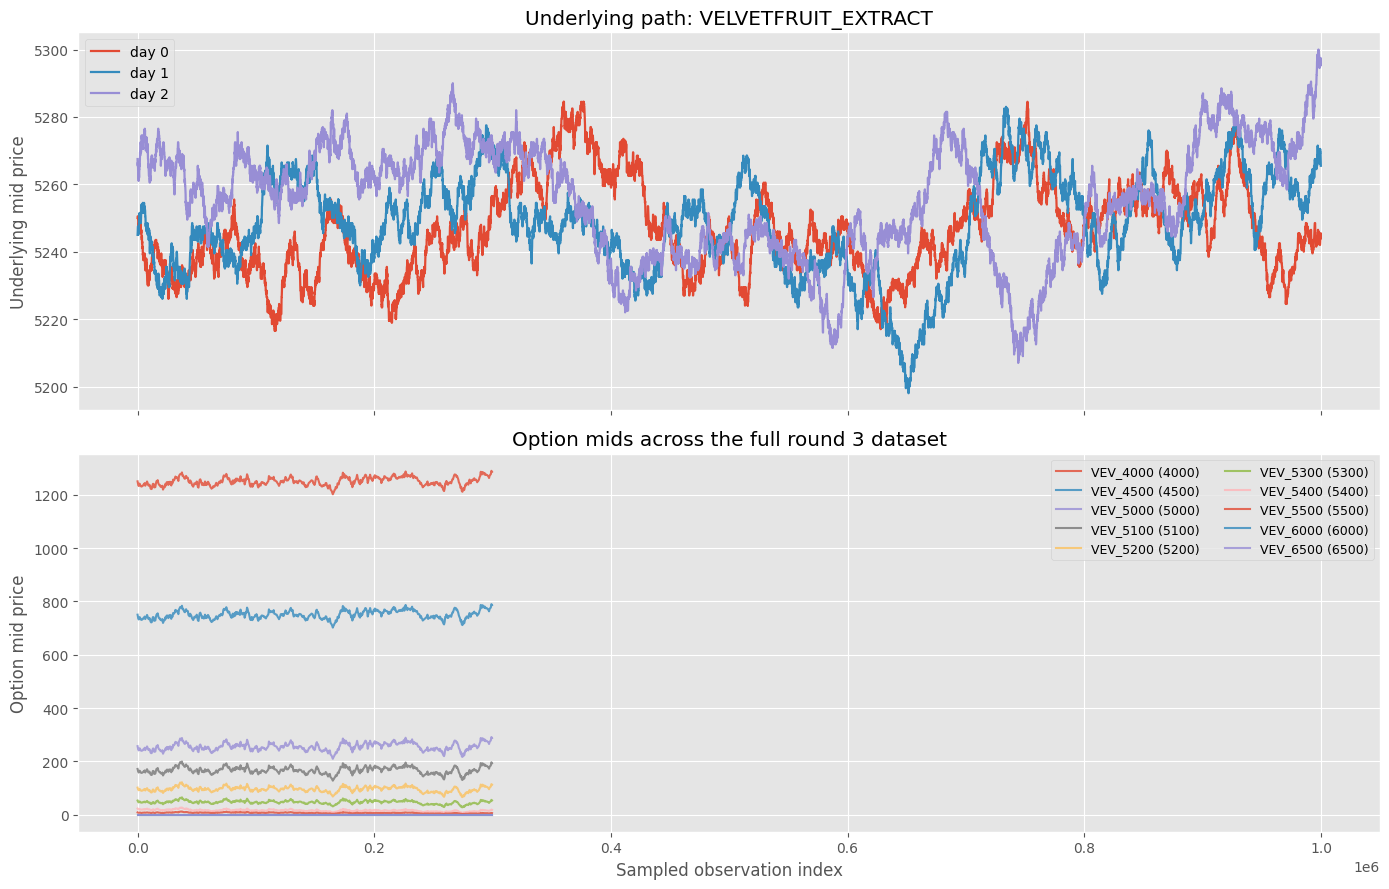

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for day, day_df in underlying_df.groupby('day'):
    axes[0].plot(day_df['timestamp'], day_df['underlying_mid'], label=f'day {day}', linewidth=1.6)

axes[0].set_title('Underlying path: VELVETFRUIT_EXTRACT')
axes[0].set_ylabel('Underlying mid price')
axes[0].legend()

for symbol, strike in OPTION_STRIKES.items():
    strike_df = options_df[options_df['product'] == symbol]
    sample = strike_df.iloc[::50]
    axes[1].plot(sample.index, sample['option_mid'], label=f'{symbol} ({strike})', alpha=0.8)

axes[1].set_title('Option mids across the full round 3 dataset')
axes[1].set_ylabel('Option mid price')
axes[1].set_xlabel('Sampled observation index')
axes[1].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


In [6]:
fit_df = options_df[
    options_df['strike'].between(FIT_STRIKE_MIN, FIT_STRIKE_MAX)
    & options_df['implied_vol'].notna()
    & (options_df['implied_vol'] > 0)
    & (options_df['extrinsic_value'] > MIN_EXTRINSIC_FOR_FIT)
].copy()

all_valid_df = options_df[
    options_df['implied_vol'].notna() & (options_df['implied_vol'] > 0)
].copy()

raw_coeffs = np.polyfit(all_valid_df['moneyness'], all_valid_df['implied_vol'], deg=2)
smile_coeffs = np.polyfit(fit_df['moneyness'], fit_df['implied_vol'], deg=2)
smile_poly = np.poly1d(smile_coeffs)

options_df['fitted_iv'] = np.clip(smile_poly(options_df['moneyness']), 0.01, 3.0)
options_df['iv_residual'] = options_df['implied_vol'] - options_df['fitted_iv']
options_df['fair_price'] = options_df.apply(
    lambda row: bs_call(row['underlying_mid'], row['strike'], row['T'], row['fitted_iv']),
    axis=1,
)
options_df['price_residual'] = options_df['option_mid'] - options_df['fair_price']
options_df['delta'] = options_df.apply(
    lambda row: bs_delta(row['underlying_mid'], row['strike'], row['T'], row['fitted_iv']),
    axis=1,
)
options_df['vega'] = options_df.apply(
    lambda row: bs_vega(row['underlying_mid'], row['strike'], row['T'], row['fitted_iv']),
    axis=1,
)

print(f'Raw fit coeffs  : {[round(float(x), 8) for x in raw_coeffs]}')
print(f'Strategy fit    : {[round(float(x), 8) for x in smile_coeffs]}')
print('This should line up with your current smile coefficients if you keep the default settings.')


Raw fit coeffs  : [0.12676126, -0.00273748, 0.26770554]
Strategy fit    : [0.02721888, 0.00285325, 0.27239067]
This should line up with your current smile coefficients if you keep the default settings.


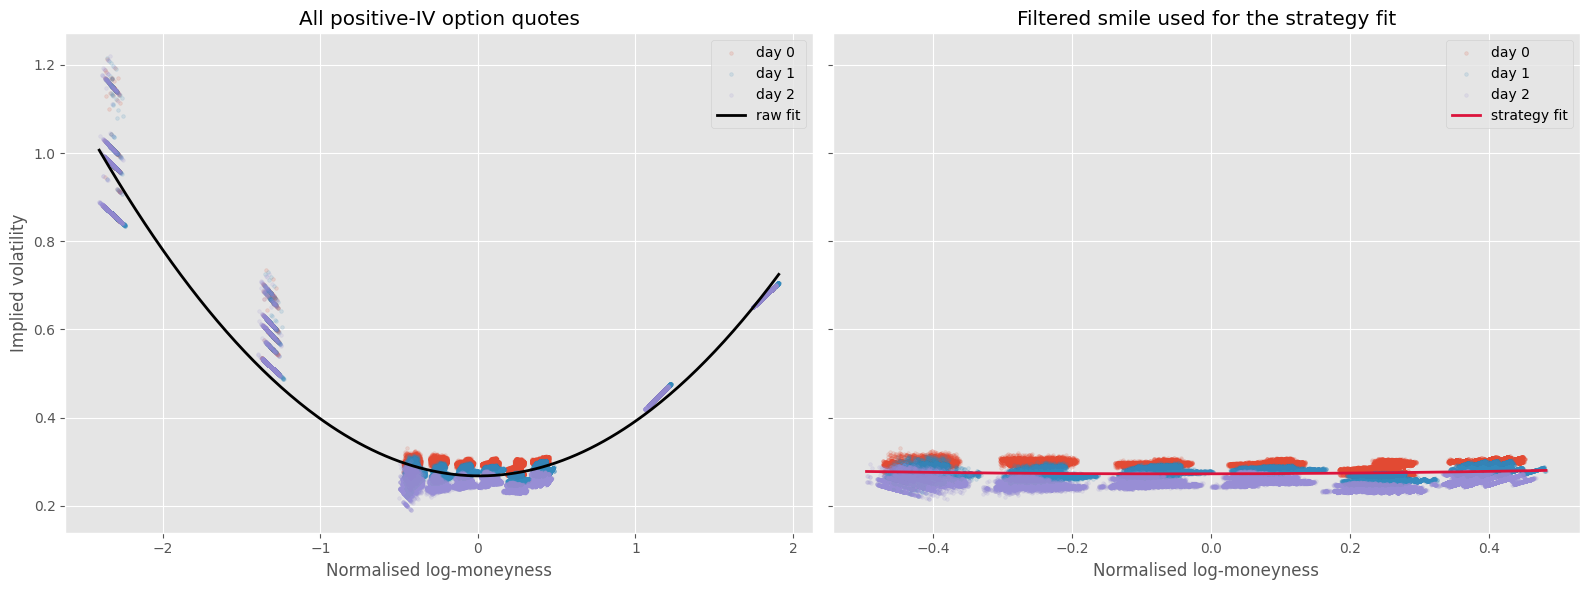

In [7]:
x_raw = np.linspace(all_valid_df['moneyness'].min(), all_valid_df['moneyness'].max(), 300)
x_fit = np.linspace(fit_df['moneyness'].min(), fit_df['moneyness'].max(), 300)

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for day, day_df in all_valid_df.groupby('day'):
    axes[0].scatter(day_df['moneyness'], day_df['implied_vol'], s=7, alpha=0.14, label=f'day {day}')
axes[0].plot(x_raw, np.poly1d(raw_coeffs)(x_raw), color='black', linewidth=2, label='raw fit')
axes[0].set_title('All positive-IV option quotes')
axes[0].set_xlabel('Normalised log-moneyness')
axes[0].set_ylabel('Implied volatility')
axes[0].legend()

for day, day_df in fit_df.groupby('day'):
    axes[1].scatter(day_df['moneyness'], day_df['implied_vol'], s=7, alpha=0.14, label=f'day {day}')
axes[1].plot(x_fit, smile_poly(x_fit), color='crimson', linewidth=2, label='strategy fit')
axes[1].set_title('Filtered smile used for the strategy fit')
axes[1].set_xlabel('Normalised log-moneyness')
axes[1].legend()

plt.tight_layout()
plt.show()


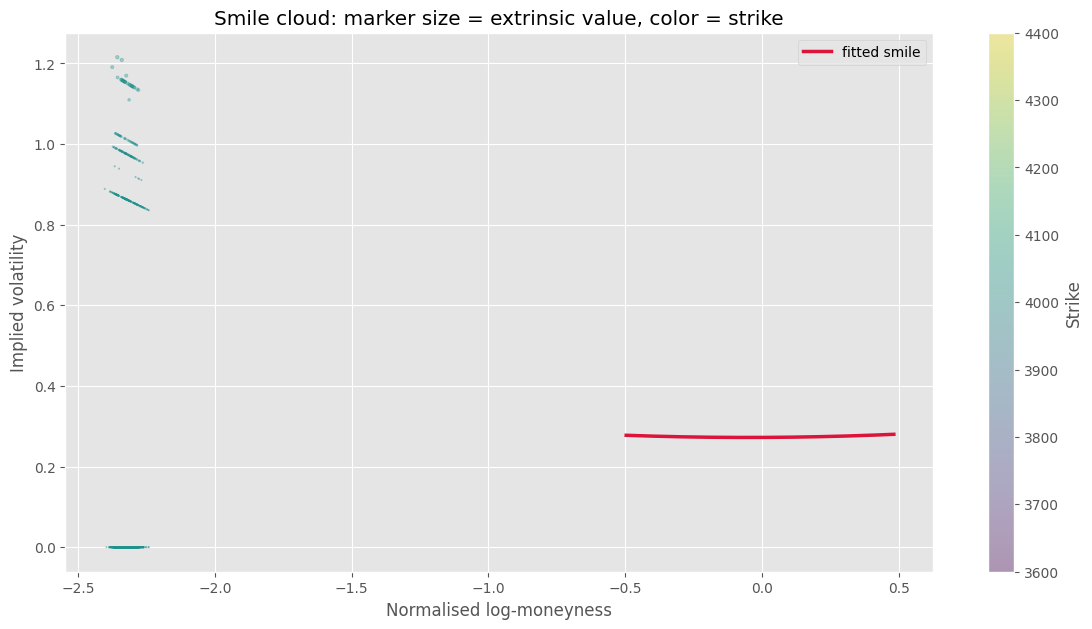

In [8]:
sampled_points = options_df.iloc[::100].copy()
fig, ax = plt.subplots(figsize=(14, 7))
scatter = ax.scatter(
    sampled_points['moneyness'],
    sampled_points['implied_vol'],
    c=sampled_points['strike'],
    s=sampled_points['extrinsic_value'].clip(lower=1.0),
    alpha=0.35,
    cmap='viridis',
)
ax.plot(x_fit, smile_poly(x_fit), color='crimson', linewidth=2.5, label='fitted smile')
ax.set_title('Smile cloud: marker size = extrinsic value, color = strike')
ax.set_xlabel('Normalised log-moneyness')
ax.set_ylabel('Implied volatility')
ax.legend()
plt.colorbar(scatter, ax=ax, label='Strike')
plt.show()


In [9]:
strike_summary = (
    options_df.groupby('product')
    .agg(
        strike=('strike', 'first'),
        avg_moneyness=('moneyness', 'mean'),
        moneyness_std=('moneyness', 'std'),
        iv_mean=('implied_vol', 'mean'),
        iv_std=('implied_vol', 'std'),
        fitted_iv_mean=('fitted_iv', 'mean'),
        iv_residual_mean=('iv_residual', 'mean'),
        iv_residual_abs_mean=('iv_residual', lambda s: s.abs().mean()),
        iv_residual_std=('iv_residual', 'std'),
        delta_mean=('delta', 'mean'),
        delta_p10=('delta', lambda s: s.quantile(0.10)),
        delta_p90=('delta', lambda s: s.quantile(0.90)),
        vega_mean=('vega', 'mean'),
        vega_p10=('vega', lambda s: s.quantile(0.10)),
        extrinsic_mean=('extrinsic_value', 'mean'),
        extrinsic_p10=('extrinsic_value', lambda s: s.quantile(0.10)),
        price_residual_std=('price_residual', 'std'),
    )
    .sort_values('strike')
)

strike_summary.round(4)


,strike,avg_moneyness,moneyness_std,iv_mean,iv_std,fitted_iv_mean,iv_residual_mean,iv_residual_abs_mean,iv_residual_std,delta_mean,delta_p10,delta_p90,vega_mean,vega_p10,extrinsic_mean,extrinsic_p10,price_residual_std
product,,,,,,,,,,,,,,,,,
VEV_4000,4000,-2.3235,0.0254,0.1031,0.2942,0.4127,-0.3096,0.4247,0.2943,1.0000,1.0000,1.0000,0.0000,0.0000,0.0117,0.0000,0.8287
VEV_4500,4500,-1.3172,0.0254,0.2208,0.2626,0.3159,-0.0950,0.2737,0.2627,1.0000,1.0000,1.0000,0.0391,0.0275,0.0115,-0.5000,0.7589
VEV_5000,5000,-0.4170,0.0254,0.2751,0.0205,0.2760,-0.0009,0.0169,0.0207,0.9359,0.9214,0.9504,76.7637,63.1798,4.9243,2.5000,1.4636
VEV_5100,5100,-0.2478,0.0254,0.2729,0.0222,0.2734,-0.0005,0.0199,0.0222,0.8208,0.7901,0.8527,160.0656,142.0902,16.7074,10.5000,3.5616
VEV_5200,5200,-0.0819,0.0254,0.2756,0.0175,0.2724,0.0032,0.0158,0.0175,0.6237,0.5790,0.6716,232.2299,223.0126,45.4504,35.0000,4.0782
VEV_5300,5300,0.0809,0.0254,0.2784,0.0152,0.2728,0.0056,0.0145,0.0152,0.3901,0.3457,0.4392,234.7764,225.7145,46.7599,38.5000,3.5615
VEV_5400,5400,0.2406,0.0254,0.2612,0.0184,0.2747,-0.0134,0.0186,0.0182,0.1960,0.1650,0.2313,169.2674,151.9702,15.9519,11.5000,3.0239
VEV_5500,5500,0.3973,0.0254,0.2832,0.0171,0.2778,0.0054,0.0154,0.0169,0.0795,0.0637,0.0981,90.6337,76.4277,6.6414,4.5000,1.5711
VEV_6000,6000,1.1408,0.0254,0.4470,0.0089,0.3111,0.1359,0.1359,0.0073,0.0001,0.0001,0.0002,0.3231,0.2359,0.5000,0.5000,0.0016


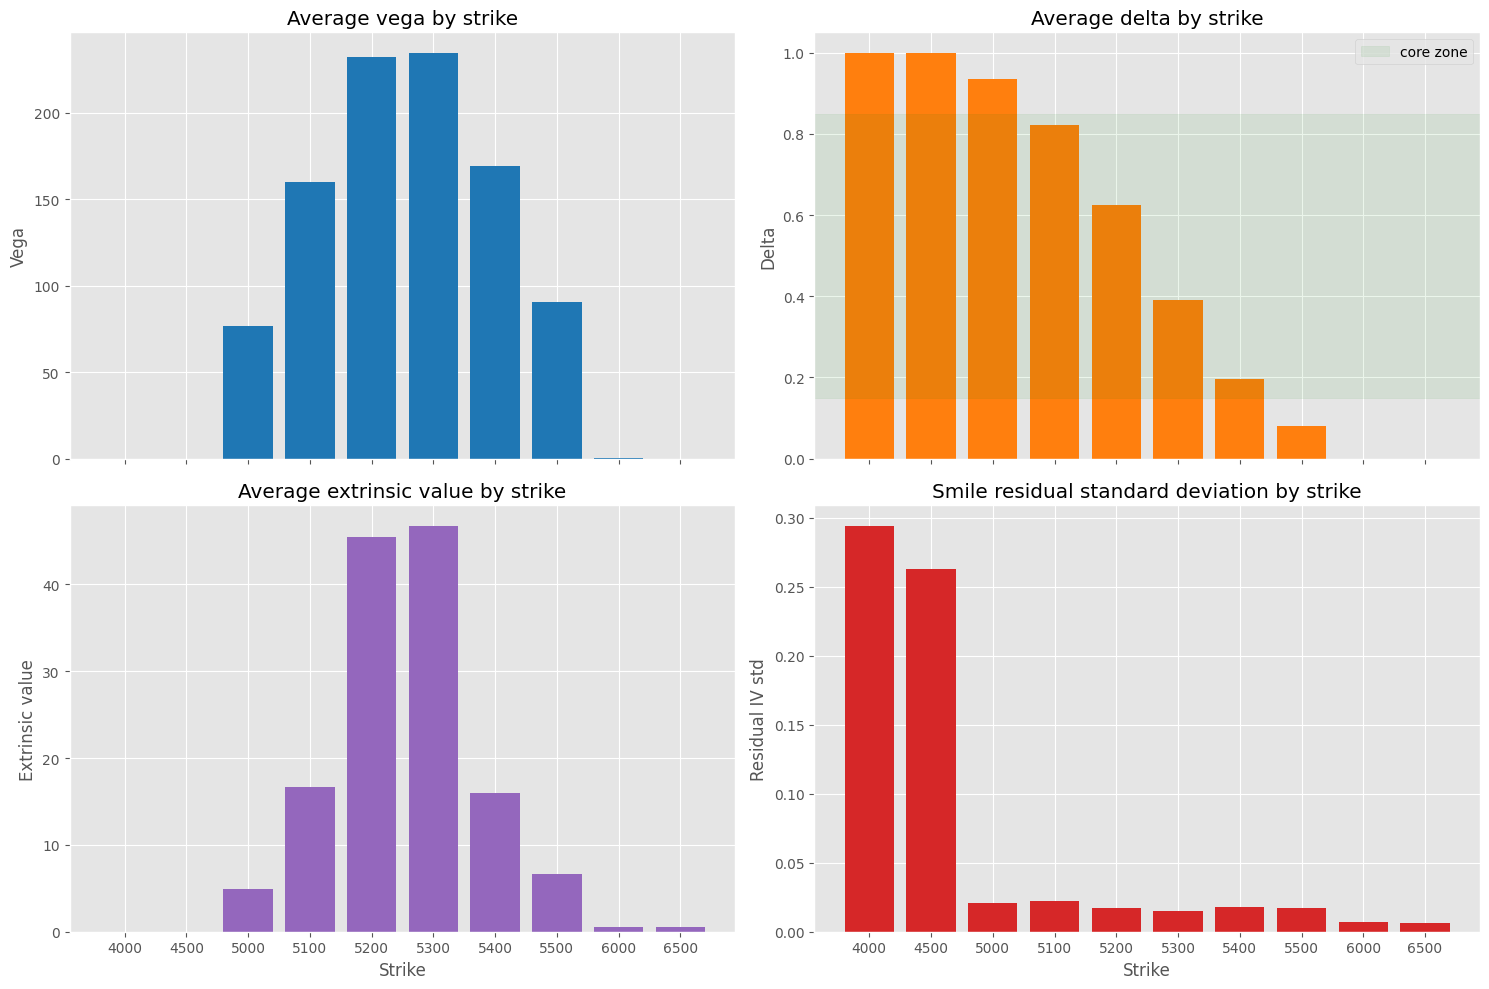

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
summary_plot = strike_summary.reset_index()
labels = [f"{int(k)}" for k in summary_plot['strike']]

axes[0, 0].bar(labels, summary_plot['vega_mean'], color='tab:blue')
axes[0, 0].set_title('Average vega by strike')
axes[0, 0].set_ylabel('Vega')

axes[0, 1].bar(labels, summary_plot['delta_mean'], color='tab:orange')
axes[0, 1].axhspan(0.15, 0.85, color='green', alpha=0.08, label='core zone')
axes[0, 1].set_title('Average delta by strike')
axes[0, 1].set_ylabel('Delta')
axes[0, 1].legend()

axes[1, 0].bar(labels, summary_plot['extrinsic_mean'], color='tab:purple')
axes[1, 0].set_title('Average extrinsic value by strike')
axes[1, 0].set_ylabel('Extrinsic value')
axes[1, 0].set_xlabel('Strike')

axes[1, 1].bar(labels, summary_plot['iv_residual_std'], color='tab:red')
axes[1, 1].set_title('Smile residual standard deviation by strike')
axes[1, 1].set_ylabel('Residual IV std')
axes[1, 1].set_xlabel('Strike')

plt.tight_layout()
plt.show()


In [11]:
decision = strike_summary.copy()
decision['core_bs_zone'] = decision['delta_mean'].between(0.15, 0.85)
decision['tradeable_zone'] = decision['delta_mean'].between(0.05, 0.95)
decision['healthy_vega'] = decision['vega_mean'] >= 100
decision['healthy_extrinsic'] = decision['extrinsic_mean'] >= 5
decision['stable_smile'] = decision['iv_residual_std'] <= 0.02

decision['quality_score'] = (
    0.35 * (decision['vega_mean'] / decision['vega_mean'].max())
    + 0.20 * (1 - (decision['delta_mean'] - 0.50).abs() / 0.50).clip(lower=0)
    + 0.20 * (decision['extrinsic_mean'] / decision['extrinsic_mean'].max()).clip(upper=1)
    + 0.25 * (1 - decision['iv_residual_std'] / decision['iv_residual_std'].max())
)


def classify_strike(row: pd.Series) -> str:
    if row['core_bs_zone'] and row['healthy_vega'] and row['healthy_extrinsic'] and row['stable_smile']:
        return 'primary'
    if row['tradeable_zone'] and row['healthy_extrinsic']:
        return 'secondary'
    return 'avoid'


def reason(row: pd.Series) -> str:
    notes = []
    if row['core_bs_zone']:
        notes.append('good delta zone')
    elif row['tradeable_zone']:
        notes.append('delta is tradable but wingy')
    else:
        notes.append('delta too extreme')

    if row['healthy_vega']:
        notes.append('strong vega')
    else:
        notes.append('weak vega')

    if row['healthy_extrinsic']:
        notes.append('enough extrinsic')
    else:
        notes.append('little extrinsic')

    if row['stable_smile']:
        notes.append('smile fit is stable')
    else:
        notes.append('smile fit is noisy')

    return ', '.join(notes)


decision['decision_bucket'] = decision.apply(classify_strike, axis=1)
decision['notes'] = decision.apply(reason, axis=1)
decision = decision.sort_values(['decision_bucket', 'quality_score'], ascending=[True, False])

decision[[
    'strike',
    'avg_moneyness',
    'delta_mean',
    'vega_mean',
    'extrinsic_mean',
    'iv_residual_std',
    'quality_score',
    'decision_bucket',
    'notes',
]].round(4)


,strike,avg_moneyness,delta_mean,vega_mean,extrinsic_mean,iv_residual_std,quality_score,decision_bucket,notes
product,,,,,,,,,
VEV_5000,5000,-0.4170,0.9359,76.7637,4.9243,0.0207,0.3936,avoid,"delta is tradable but wingy, weak vega, little..."
VEV_6500,6500,1.8247,0.0000,0.0013,0.5000,0.0060,0.2471,avoid,"delta too extreme, weak vega, little extrinsic..."
VEV_6000,6000,1.1408,0.0001,0.3231,0.5000,0.0073,0.2465,avoid,"delta too extreme, weak vega, little extrinsic..."
VEV_4500,4500,-1.3172,1.0000,0.0391,0.0115,0.2627,0.0269,avoid,"delta too extreme, weak vega, little extrinsic..."
VEV_4000,4000,-2.3235,1.0000,0.0000,0.0117,0.2943,0.0001,avoid,"delta too extreme, weak vega, little extrinsic..."
VEV_5300,5300,0.0809,0.3901,234.7764,46.7599,0.0152,0.9431,primary,"good delta zone, strong vega, enough extrinsic..."
VEV_5200,5200,-0.0819,0.6237,232.2299,45.4504,0.0175,0.9262,primary,"good delta zone, strong vega, enough extrinsic..."
VEV_5400,5400,0.2406,0.1960,169.2674,15.9519,0.0182,0.6335,primary,"good delta zone, strong vega, enough extrinsic..."
VEV_5100,5100,-0.2478,0.8208,160.0656,16.7074,0.0222,0.6129,secondary,"good delta zone, strong vega, enough extrinsic..."


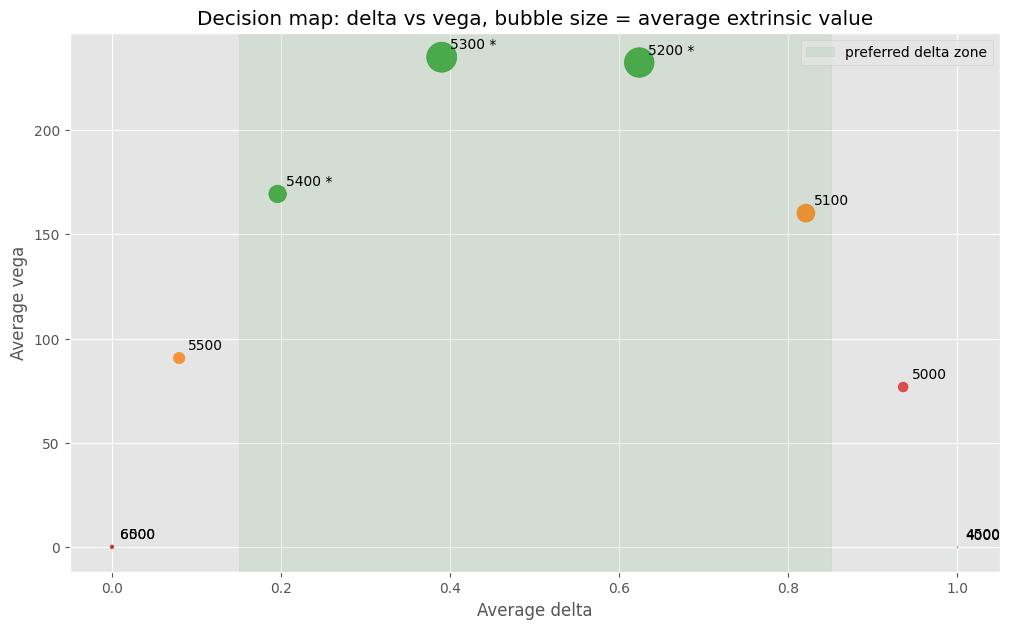

In [12]:
decision_plot = decision.sort_values('strike').reset_index()
color_map = {'primary': 'tab:green', 'secondary': 'tab:orange', 'avoid': 'tab:red'}
colors = decision_plot['decision_bucket'].map(color_map)

fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(
    decision_plot['delta_mean'],
    decision_plot['vega_mean'],
    s=decision_plot['extrinsic_mean'] * 10,
    c=colors,
    alpha=0.8,
)
for _, row in decision_plot.iterrows():
    label = f"{int(row['strike'])}"
    if int(row['strike']) in STRATEGY_TRADE_STRIKES:
        label += ' *'
    ax.annotate(label, (row['delta_mean'], row['vega_mean']), textcoords='offset points', xytext=(6, 6))

ax.axvspan(0.15, 0.85, color='green', alpha=0.08, label='preferred delta zone')
ax.set_title('Decision map: delta vs vega, bubble size = average extrinsic value')
ax.set_xlabel('Average delta')
ax.set_ylabel('Average vega')
ax.legend()
plt.show()


In [13]:
primary = decision[decision['decision_bucket'] == 'primary'].sort_values('quality_score', ascending=False)
secondary = decision[decision['decision_bucket'] == 'secondary'].sort_values('quality_score', ascending=False)
avoid = decision[decision['decision_bucket'] == 'avoid'].sort_values('strike')

print('Primary candidates for a Black-Scholes smile strategy:')
if len(primary) == 0:
    print('  none under the current thresholds')
else:
    for row in primary.itertuples():
        print(
            f"  strike {int(row.strike)}: moneyness={row.avg_moneyness:0.3f}, "
            f"delta={row.delta_mean:0.3f}, vega={row.vega_mean:0.1f}, "
            f"residual_std={row.iv_residual_std:0.4f}"
        )

print('\nSecondary candidates:')
if len(secondary) == 0:
    print('  none under the current thresholds')
else:
    for row in secondary.itertuples():
        print(
            f"  strike {int(row.strike)}: moneyness={row.avg_moneyness:0.3f}, "
            f"delta={row.delta_mean:0.3f}, vega={row.vega_mean:0.1f}, "
            f"residual_std={row.iv_residual_std:0.4f}"
        )

print('\nAvoid for smile trading / coefficient fitting:')
for row in avoid.itertuples():
    print(
        f"  strike {int(row.strike)}: delta={row.delta_mean:0.3f}, "
        f"vega={row.vega_mean:0.3f}, extrinsic={row.extrinsic_mean:0.3f}, notes={row.notes}"
    )


Primary candidates for a Black-Scholes smile strategy:
  strike 5300: moneyness=0.081, delta=0.390, vega=234.8, residual_std=0.0152
  strike 5200: moneyness=-0.082, delta=0.624, vega=232.2, residual_std=0.0175
  strike 5400: moneyness=0.241, delta=0.196, vega=169.3, residual_std=0.0182

Secondary candidates:
  strike 5100: moneyness=-0.248, delta=0.821, vega=160.1, residual_std=0.0222
  strike 5500: moneyness=0.397, delta=0.080, vega=90.6, residual_std=0.0169

Avoid for smile trading / coefficient fitting:
  strike 4000: delta=1.000, vega=0.000, extrinsic=0.012, notes=delta too extreme, weak vega, little extrinsic, smile fit is noisy
  strike 4500: delta=1.000, vega=0.039, extrinsic=0.011, notes=delta too extreme, weak vega, little extrinsic, smile fit is noisy
  strike 5000: delta=0.936, vega=76.764, extrinsic=4.924, notes=delta is tradable but wingy, weak vega, little extrinsic, smile fit is noisy
  strike 6000: delta=0.000, vega=0.323, extrinsic=0.500, notes=delta too extreme, weak 

## Reading the output

A good Black-Scholes smile-trading strike usually has all four of these properties:
- moneyness not too far into the wings
- delta far enough away from `0` and `1` that the option still reacts smoothly
- strong vega so an IV mispricing turns into a meaningful price edge
- stable smile residuals so you are trading signal rather than just tick noise

In this dataset, the notebook is set up to make that trade-off explicit. In practice you should expect:
- `5200`, `5300`, and `5400` to emerge as the best core smile-trading set
- `5100` to be usable, but more directional than the centre strikes
- `5000` and `5500` to be borderline wings: still informative, but weaker for sizing
- `4000`, `4500`, `6000`, and `6500` to behave like structural outliers or minimum-tick noise rather than reliable BS signals

If you want to stress-test the conclusion, rerun the notebook with `DECAY_DAYS_ACROSS_FILES = True` and compare how stable the rankings remain.
